In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
Path("data").mkdir(exist_ok=True)

DATA_CANDIDATES = [
    Path("data/PRSA_data_2010.1.1-2014.12.31.csv"),
    Path("PRSA_data_2010.1.1-2014.12.31.csv"),
    Path("PRSA_data.csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("PRSA_data_2010.1.1-2014.12.31 (1)")


# Stage 0

## Stage 0.1 - Load Dataset and Basic Inspection


In [2]:
raw = pd.read_csv(DATA_PATH)
raw["datetime"] = pd.to_datetime(raw[["year", "month", "day", "hour"]])
raw = raw.sort_values("datetime").reset_index(drop=True)

print(f"Loaded dataset: {DATA_PATH}")
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns")
print(f"Datetime range: {raw['datetime'].min()} to {raw['datetime'].max()}")
print(f"Duplicate full rows: {raw.duplicated().sum()}")
print(f"Duplicate timestamps: {raw['datetime'].duplicated().sum()}")
display(raw.head())


Loaded dataset: PRSA_data_2010.1.1-2014.12.31.csv
Raw shape: 43,824 rows x 14 columns
Datetime range: 2010-01-01 00:00:00 to 2014-12-31 23:00:00
Duplicate full rows: 0
Duplicate timestamps: 0


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,datetime
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00


During this stage, the Beijing PM2.5 dataset was uploaded into the computer. A proper time column was created by combining the year, month, day, and hour columns. The data was then arranged based on time because this problem involves hourly and daily patterns. After that, the dataset size, date range, and duplicate rows were checked. This step was important to make sure the dataset was loaded correctly before any data cleaning or feature engineering was done.


## Stage 0.2 - Missing Value Audit


In [3]:
## Stage 0.2 - Missing Value Audit


missing_report = pd.DataFrame({
    "column": raw.columns,
    "missing_count": raw.isna().sum().values,
    "missing_percent": raw.isna().mean().values * 100,
})

missing_report["strategy"] = np.where(
    missing_report["missing_count"].eq(0),
    "No action needed",
    "Drop for modelling because this is the target label",
)

display(missing_report)

,column,missing_count,missing_percent,strategy
0,No,0,0.000000,No action needed
1,year,0,0.000000,No action needed
2,month,0,0.000000,No action needed
3,day,0,0.000000,No action needed
4,hour,0,0.000000,No action needed
5,pm2.5,2067,4.716594,Drop for modelling because this is the target ...
6,DEWP,0,0.000000,No action needed
7,TEMP,0,0.000000,No action needed
8,PRES,0,0.000000,No action needed
9,cbwd,0,0.000000,No action needed


At this step, the missing values in every column of the dataset were checked. During the audit, the target column, PM2.5, was found to contain some missing values. Since PM2.5 is the value that we want to predict, these missing values were not filled with estimated values. The rows with missing PM2.5 values were removed because the model needs real target values during the training process.


## Stage 0.3 - Cleaning Decision


In [4]:
clean_df = raw.dropna(subset=["pm2.5"]).copy().reset_index(drop=True)
clean_df.to_csv("data/PRSA_stage0_clean.csv", index=False)

print(f"Rows before cleaning: {len(raw):,}")
print(f"Rows after dropping missing target pm2.5: {len(clean_df):,}")
print(f"Rows removed: {len(raw) - len(clean_df):,} ({(len(raw) - len(clean_df)) / len(raw) * 100:.2f}%)")
print(f"Remaining missing values: {clean_df.isna().sum().sum()}")


Rows before cleaning: 43,824
Rows after dropping missing target pm2.5: 41,757
Rows removed: 2,067 (4.72%)
Remaining missing values: 0


In this stage, the dataset was cleaned by removing rows where the PM2.5 target value was missing. This was done because the PM2.5 value is needed for the model to learn. Without the PM2.5 target value, those rows are not useful for training.

After that, the number of rows before and after cleaning was compared. This comparison shows how many rows were removed from the dataset.

The good thing is that only a small percentage of rows were removed. This means removing rows with missing PM2.5 values was a suitable decision. The dataset is still reliable and can still be used for modelling the PM2.5 target value.


## Stage 0.4 - Outlier Analysis


,column,q1,q3,lower_fence,upper_fence,iqr_outlier_count,outlier_percent,decision
9,Iws,1.79,21.91,-28.39,52.09,4893,11.717796,Keep
5,pm2.5,29.00,137.00,-133.00,299.00,1773,4.245995,Keep
11,Ir,0.00,0.00,0.00,0.00,1739,4.164571,Keep
10,Is,0.00,0.00,0.00,0.00,368,0.881289,Keep
3,day,8.00,23.00,-14.50,45.50,0,0.000000,Keep
2,month,4.00,10.00,-5.00,19.00,0,0.000000,Keep
1,year,2011.00,2013.00,2008.00,2016.00,0,0.000000,Keep
0,No,11464.00,33262.00,-21233.00,65959.00,0,0.000000,Keep
7,TEMP,2.00,23.00,-29.50,54.50,0,0.000000,Keep
6,DEWP,-10.00,15.00,-47.50,52.50,0,0.000000,Keep


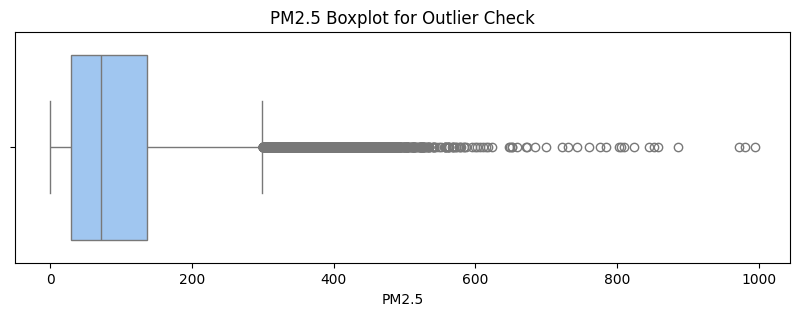

In [5]:
numeric_cols = clean_df.select_dtypes(include=[np.number]).columns
outlier_rows = []

for col in numeric_cols:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((clean_df[col] < lower) | (clean_df[col] > upper)).sum()
    outlier_rows.append([col, q1, q3, lower, upper, count, count / len(clean_df) * 100, "Keep"])

outlier_report = pd.DataFrame(
    outlier_rows,
    columns=["column", "q1", "q3", "lower_fence", "upper_fence", "iqr_outlier_count", "outlier_percent", "decision"],
).sort_values("outlier_percent", ascending=False)

display(outlier_report.head(12))

plt.figure(figsize=(10, 3))
sns.boxplot(x=clean_df["pm2.5"], color="#93c5fd")
plt.title("PM2.5 Boxplot for Outlier Check")
plt.xlabel("PM2.5")
plt.show()


At this point, outliers in the dataset were checked using the IQR method. A boxplot for PM2.5 was also created to show the distribution of the values. The result shows that PM2.5 has some high values.

These high PM2.5 values were kept because they may represent real pollution events. They are not necessarily data errors. If the high PM2.5 values were removed, the model might not learn properly from extreme air pollution cases with high PM2.5 levels.


## Stage 0.5 - Class Distribution / Imbalance Check


In [6]:
task_type = "time-series regression"
target_column = "pm2.5"

print(f"Task type: {task_type}")
print(f"Target column: {target_column}")
print("Class distribution and SMOTE are not applicable because the target is continuous, not categorical.")


Task type: time-series regression
Target column: pm2.5
Class distribution and SMOTE are not applicable because the target is continuous, not categorical.


At this point, the dataset was checked to see whether class imbalance needed to be handled. The main focus is the PM2.5 column, which is a numerical value. This means the project is a regression problem, not a classification problem. Therefore, class imbalance is not an issue, and methods like SMOTE are not needed for this dataset.


## Stage 0.6 - EDA Plot 1: PM2.5 Over Time


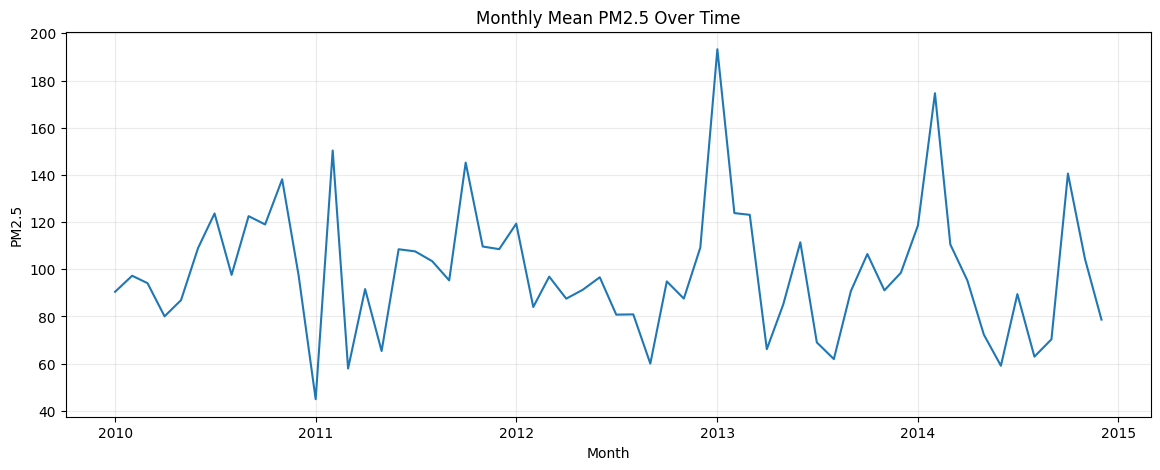

In [7]:
monthly_pm25 = clean_df.set_index("datetime")["pm2.5"].resample("MS").mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_pm25.index, monthly_pm25.values)
plt.title("Monthly Mean PM2.5 Over Time")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.grid(alpha=0.25)
plt.show()


In this stage, the average PM2.5 values were plotted over time. This plot helps to show the trend and pattern of air pollution across the years. Since PM2.5 changes over time, this project can be treated as a time-series problem.

Because the data has a time order, it is better to use a time-based train-test split instead of a random split.


## Stage 0.7 - EDA Plot 2: Correlation Heatmap


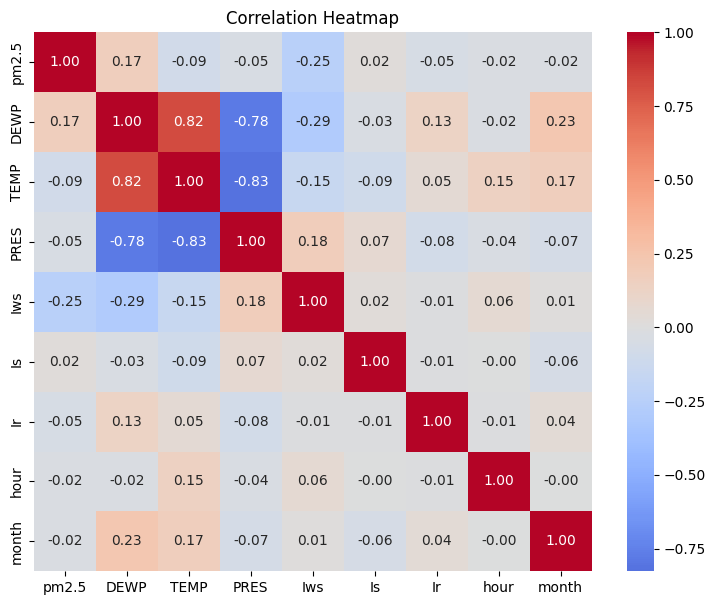

In [8]:
corr_cols = ["pm2.5", "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir", "hour", "month"]
corr = clean_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In this stage we used a correlation heatmap to see how PM2.5 is related to numerical features like temperature, pressure, dew point, wind speed, hour and month. This helps us figure out which variables have an weaker connection with PM2.5. We found that some of these connections are not very strong. The features can still be helpful when we use them with time-based features, in the baseline model for PM2.5.

## Stage 0.8 - Feature Engineering


Model-ready rows: 40,497
Rows removed after creating lag/rolling features: 1,260


,datetime,pm2.5,pm25_lag1,pm25_lag24,pm25_roll24_mean,hour_sin,hour_cos,month_sin,month_cos,cbwd
0,2010-01-03 00:00:00,90.0,126.0,129.0,145.958333,0.000000,1.000000,0.5,0.866025,SE
1,2010-01-03 01:00:00,63.0,90.0,148.0,144.333333,0.258819,0.965926,0.5,0.866025,SE
2,2010-01-03 02:00:00,65.0,63.0,159.0,140.791667,0.500000,0.866025,0.5,0.866025,SE
3,2010-01-03 03:00:00,55.0,65.0,181.0,136.875000,0.707107,0.707107,0.5,0.866025,SE
4,2010-01-03 04:00:00,65.0,55.0,138.0,131.625000,0.866025,0.500000,0.5,0.866025,SE


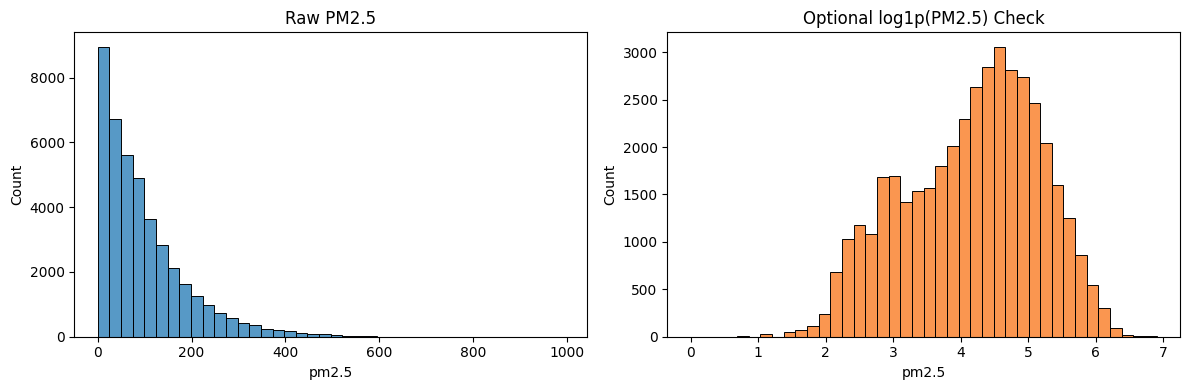

In [9]:
# Lag features are created before dropping rows so lag1 and lag24 still mean actual previous-hour values.
model_df = raw.copy()
model_df["pm25_lag1"] = model_df["pm2.5"].shift(1)
model_df["pm25_lag24"] = model_df["pm2.5"].shift(24)
model_df["pm25_roll24_mean"] = model_df["pm2.5"].shift(1).rolling(24, min_periods=12).mean()

# Cyclical encoding helps linear regression represent hour/month cycles.
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

needed = ["pm2.5", "pm25_lag1", "pm25_lag24", "pm25_roll24_mean"]
model_df = model_df.dropna(subset=needed).copy().reset_index(drop=True)
model_df.to_csv("data/PRSA_stageA_model_ready.csv", index=False)

print(f"Model-ready rows: {len(model_df):,}")
print(f"Rows removed after creating lag/rolling features: {len(clean_df) - len(model_df):,}")
display(model_df[["datetime", "pm2.5", "pm25_lag1", "pm25_lag24", "pm25_roll24_mean", "hour_sin", "hour_cos", "month_sin", "month_cos", "cbwd"]].head())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(clean_df["pm2.5"], bins=40)
plt.title("Raw PM2.5")
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(clean_df["pm2.5"]), bins=40, color="#f97316")
plt.title("Optional log1p(PM2.5) Check")
plt.tight_layout()
plt.show()


In this stage, new features were created to help the model understand PM2.5 patterns better. We added lag features, such as the PM2.5 value from the previous hour and the same hour from the day before, because current pollution is usually related to past pollution levels. We also calculated a 24-hour average to show the recent pollution trend.

For hour and month, sine and cosine features were used because time moves in a cycle. Wind direction was converted into codes because it is categorical data, and linear regression cannot use it directly. For Stage A, PM2.5 was used as the target value. Since this is a baseline model, the features were kept simple and easy to understand.


# Stage A

## Stage A.1 - Temporal Train/Test Split


In [10]:
feature_cols = [
    "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir",
    "pm25_lag1", "pm25_lag24", "pm25_roll24_mean",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "cbwd",
]

X = pd.get_dummies(model_df[feature_cols], columns=["cbwd"], dtype=float)
y = model_df["pm2.5"].to_numpy(float)

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Train period: {model_df['datetime'].iloc[0]} to {model_df['datetime'].iloc[split_idx - 1]}")
print(f"Test period: {model_df['datetime'].iloc[split_idx]} to {model_df['datetime'].iloc[-1]}")
print("Split method: chronological 80/20 split; no random shuffle.")


Train rows: 32,397
Test rows: 8,100
Train period: 2010-01-03 00:00:00 to 2014-01-19 05:00:00
Test period: 2014-01-19 06:00:00 to 2014-12-31 23:00:00
Split method: chronological 80/20 split; no random shuffle.


In A1, the dataset was divided using a chronological 80/20 train-test split. The first 80% of the data was used for training, while the remaining 20% was used for testing. This method was chosen because the task is a time-series regression problem. The data was not shuffled because random shuffling may cause data leakage, where future information can accidentally be included in the training process. Therefore, using a chronological split makes the testing process more realistic, as the model is tested using future PM2.5 values.


## Stage A.2 - Baseline Model: Linear Regression from Scratch with NumPy


In [11]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0).replace(0, 1)

Xtr = ((X_train - mu) / sigma).to_numpy(float)
Xte = ((X_test - mu) / sigma).to_numpy(float)

Xtr_i = np.c_[np.ones(len(Xtr)), Xtr]
Xte_i = np.c_[np.ones(len(Xte)), Xte]

beta = np.linalg.lstsq(Xtr_i, y_train, rcond=None)[0]
y_pred = np.clip(Xte_i @ beta, 0, None)

print(f"Training matrix shape: {Xtr_i.shape}")
print(f"Testing matrix shape: {Xte_i.shape}")
print(f"Number of coefficients including intercept: {len(beta)}")


Training matrix shape: (32397, 18)
Testing matrix shape: (8100, 18)
Number of coefficients including intercept: 18


In A2, we created a Linear Regression model using NumPy. This model was used as a simple baseline model for comparison with future improved models. Before training the model, the features were standardised using only the training data to prevent data leakage.

Linear Regression is suitable as a baseline model because it is simple, straightforward, and easy to understand. It also helps us check whether the engineered features can reasonably predict PM2.5 levels. By using this model, we can compare the performance of more advanced models later and see whether they give better results.


## Stage A.3 - Metric Table


In [12]:
def regression_metrics(y_true, pred):
    mae = np.mean(np.abs(y_true - pred))
    rmse = np.sqrt(np.mean((y_true - pred) ** 2))
    r2 = 1 - np.sum((y_true - pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape

metric_table = pd.DataFrame([
    ("Stage A: NumPy Linear Regression", *regression_metrics(y_test, y_pred)),
    ("Sanity check: previous-hour persistence", *regression_metrics(y_test, X_test["pm25_lag1"].to_numpy(float))),
    ("Dummy check: train-mean prediction", *regression_metrics(y_test, np.full_like(y_test, y_train.mean()))),
], columns=["model", "MAE", "RMSE", "R2", "MAPE_percent"])

display(metric_table)


,model,MAE,RMSE,R2,MAPE_percent
0,Stage A: NumPy Linear Regression,11.624861,20.433567,0.949733,23.023393
1,Sanity check: previous-hour persistence,11.517037,21.114000,0.946329,20.240281
2,Dummy check: train-mean prediction,68.231162,91.186477,-0.001051,232.783747


In A3, we evaluated the performance of the baseline model using several metrics, such as MAE, RMSE, R² and MAPE. These metrics help us understand how close the predicted PM2.5 values are to the actual PM2.5 values.

MAE and RMSE show the amount of error made by the model when predicting PM2.5 values. Meanwhile, R² shows how well the model can explain the changes in the PM2.5 values. MAPE also helps us understand the prediction error in percentage form.

Based on the results, the baseline model performed better than simply predicting the average PM2.5 value. This shows that the features used in the model have some ability to predict PM2.5 levels.


## Stage A.4 - Baseline Prediction Plot and Coefficients


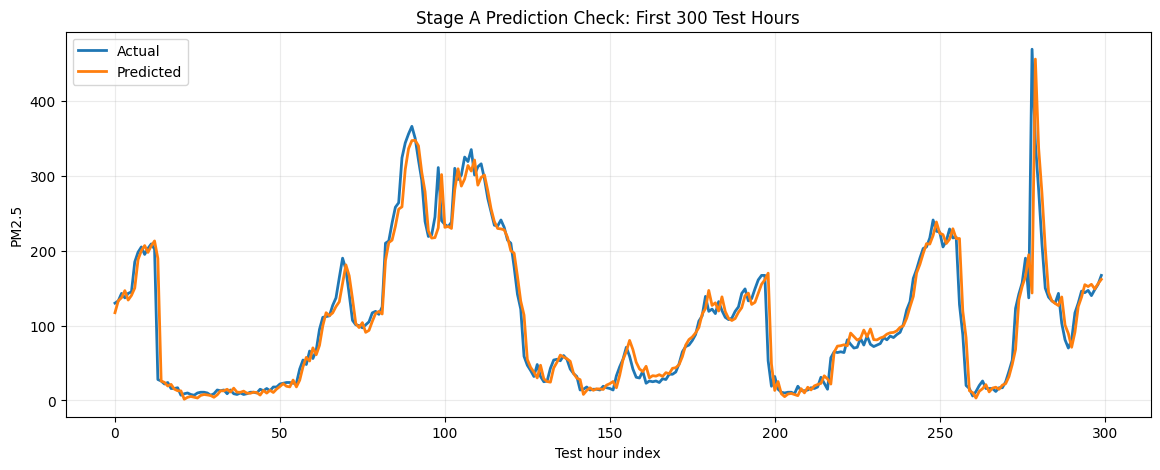

,feature,coefficient_on_scaled_feature,abs_coef
6,pm25_lag1,87.093496,87.093496
1,TEMP,-7.299405,7.299405
0,DEWP,7.095493,7.095493
9,hour_sin,-2.845702,2.845702
14,cbwd_NW,-2.202145,2.202145
12,month_cos,1.759743,1.759743
2,PRES,-1.648779,1.648779
8,pm25_roll24_mean,-1.545464,1.545464
16,cbwd_cv,1.463701,1.463701
11,month_sin,1.263158,1.263158


In [13]:
n_plot = min(300, len(y_test))
plt.figure(figsize=(14, 5))
plt.plot(y_test[:n_plot], label="Actual", linewidth=2)
plt.plot(y_pred[:n_plot], label="Predicted", linewidth=2)
plt.title("Stage A Prediction Check: First 300 Test Hours")
plt.xlabel("Test hour index")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient_on_scaled_feature": beta[1:],
})
coef_table["abs_coef"] = coef_table["coefficient_on_scaled_feature"].abs()
display(coef_table.sort_values("abs_coef", ascending=False).head(12))


In A3, we evaluated the baseline model using regression metrics such as MAE, RMSE, R², and MAPE. These metrics help us measure how close the predicted PM2.5 values are to the actual values. MAE and RMSE show the prediction error made by the model, while R² shows how much variation in PM2.5 can be explained by the model. MAPE shows the prediction error in percentage form, which makes the result easier to understand. Based on the results, the baseline model performs much better than simply predicting the average PM2.5 value.


# Stage B

In [14]:
required_objects = ["model_df", "X_train", "X_test", "y_train", "y_test", "regression_metrics"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "Run Stage 0 and Stage A first. Missing objects: " + ", ".join(missing_objects)
    )

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Path("outputs").mkdir(exist_ok=True)

RANDOM_STATE = 42
print("Ready for Stage B and Stage C.")
print(f"Training rows: {len(X_train):,}, Testing rows: {len(X_test):,}")

Ready for Stage B and Stage C.
Training rows: 32,397, Testing rows: 8,100


## Stage B.1 - Ensemble Model: Tuned Random Forest

Random Forest was used as the ensemble or intermediate model in this project. This model is useful because it can capture non-linear relationships between meteorological features, lag features, and PM2.5 values. This means it can learn more complex patterns compared to the baseline Linear Regression model.

For hyperparameter tuning, `TimeSeriesSplit` was used instead of random K-fold splitting. This is because the dataset follows a chronological order. Using `TimeSeriesSplit` helps prevent data leakage and makes the evaluation more suitable for a time-series prediction problem.


In [15]:
# Stage B: Random Forest with time-series cross-validation.

ts_cv = TimeSeriesSplit(n_splits=3)

rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [80, 120, 180],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 1.0],
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=8,
    scoring="neg_mean_absolute_error",
    cv=ts_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
rf_pred = np.clip(rf_best.predict(X_test), 0, None)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print(f"Best CV MAE: {-rf_search.best_score_:.4f}")

cv_results = pd.DataFrame(rf_search.cv_results_)
cv_cols = ["mean_test_score", "std_test_score", "param_n_estimators", "param_max_depth", "param_min_samples_split", "param_min_samples_leaf", "param_max_features"]
cv_results_display = cv_results[cv_cols].copy()
cv_results_display["mean_CV_MAE"] = -cv_results_display["mean_test_score"]
cv_results_display = cv_results_display.sort_values("mean_CV_MAE")

display(cv_results_display[["mean_CV_MAE", "std_test_score", "param_n_estimators", "param_max_depth", "param_min_samples_split", "param_min_samples_leaf", "param_max_features"]])
cv_results_display.to_csv("outputs/stageB_random_forest_cv_results.csv", index=False)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest parameters:
{'n_estimators': 80, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 12}
Best CV MAE: 13.0896


,mean_CV_MAE,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
5,13.089564,0.664073,80,12,2,4,0.7
0,13.109753,0.715315,80,12,10,4,0.7
7,13.300186,0.726345,120,16,10,1,0.7
1,13.328264,0.772565,80,12,2,1,0.7
2,13.622876,1.108569,180,12,2,1,1.0
6,13.664778,0.940831,80,16,5,1,1.0
4,15.309586,1.058647,80,16,2,4,sqrt
3,18.279892,1.061534,80,8,2,2,sqrt


## Stage B.2 - Random Forest Feature Importance

This plot helps explain which variables the ensemble model uses most. For this dataset, lagged PM2.5 variables are expected to be important because air pollution has temporal persistence.

,feature,importance
6,pm25_lag1,0.837089
8,pm25_roll24_mean,0.104327
7,pm25_lag24,0.020015
3,Iws,0.009396
0,DEWP,0.006341
14,cbwd_NW,0.005979
1,TEMP,0.003525
12,month_cos,0.002737
9,hour_sin,0.002616
2,PRES,0.002422


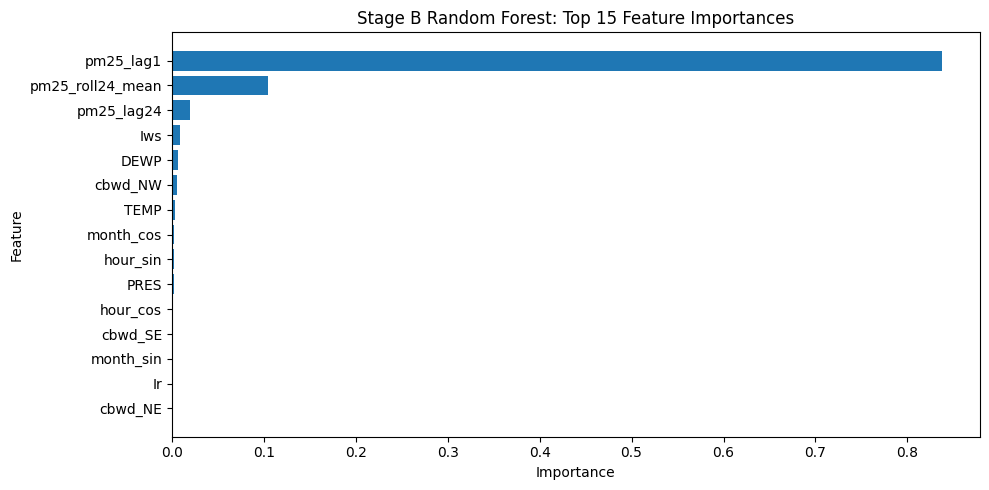

In [16]:
rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_best.feature_importances_,
}).sort_values("importance", ascending=False)

rf_importance.to_csv("outputs/stageB_random_forest_feature_importance.csv", index=False)
display(rf_importance.head(15))

plt.figure(figsize=(10, 5))
plt.barh(rf_importance.head(15)["feature"][::-1], rf_importance.head(15)["importance"][::-1])
plt.title("Stage B Random Forest: Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("outputs/stageB_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Stage C

## Stage C.1 - Deep Learning Model: LSTM Sequence Model

The deep learning model use the previous 24 hours as an input sequence. This more suitable for a time-series dataset rarther than a plain dense model because the LSTM can learn patterns across ordered hourly readings. Scaling is fitted to the training period only to avoid leakage.

In [17]:
# Stage C: LSTM sequence model.
# This uses previous 24 hours to predict the current PM2.5 value.

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.optimizers import Adam
except Exception as e:
    raise ImportError(
        "TensorFlow is required for Stage C. In Colab, run: !pip install tensorflow"
    ) from e

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

seq_len = 24
split_idx = int(len(model_df) * 0.8)

# Use past PM2.5 plus weather and time features as sequence inputs.
dl_feature_cols = [
    "pm2.5", "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "cbwd"
]

seq_features = pd.get_dummies(model_df[dl_feature_cols], columns=["cbwd"], dtype=float)
seq_target = model_df["pm2.5"].to_numpy(float)

# Fit scaler on training period only.
seq_scaler = StandardScaler()
seq_scaler.fit(seq_features.iloc[:split_idx])
seq_values = seq_scaler.transform(seq_features)

def make_sequences(values, target, seq_len, start_target_idx, end_target_idx):
    X_seq, y_seq = [], []
    first_target = max(seq_len, start_target_idx)
    for t in range(first_target, end_target_idx):
        X_seq.append(values[t - seq_len:t])
        y_seq.append(target[t])
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)

X_seq_train, y_seq_train = make_sequences(seq_values, seq_target, seq_len, seq_len, split_idx)
X_seq_test, y_seq_test = make_sequences(seq_values, seq_target, seq_len, split_idx, len(seq_target))

# Scale target for stable neural network training, then inverse-transform predictions later.
y_scaler = StandardScaler()
y_seq_train_scaled = y_scaler.fit_transform(y_seq_train.reshape(-1, 1)).ravel()

print(f"LSTM train sequence shape: {X_seq_train.shape}")
print(f"LSTM test sequence shape: {X_seq_test.shape}")
print(f"LSTM test target rows match Stage A/B test rows: {len(y_seq_test) == len(y_test)}")

lstm_model = Sequential([
    Input(shape=(seq_len, X_seq_train.shape[2])),
    LSTM(64),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1),
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"],
)

lstm_model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = lstm_model.fit(
    X_seq_train,
    y_seq_train_scaled,
    validation_split=0.20,
    epochs=30,
    batch_size=64,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

lstm_pred_scaled = lstm_model.predict(X_seq_test, verbose=0).ravel()
lstm_pred = y_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).ravel()
lstm_pred = np.clip(lstm_pred, 0, None)

LSTM train sequence shape: (32373, 24, 15)
LSTM test sequence shape: (8100, 24, 15)
LSTM test target rows match Stage A/B test rows: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.2461 - mae: 0.3335 - val_loss: 0.0997 - val_mae: 0.2191
Epoch 2/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1255 - mae: 0.2280 - val_loss: 0.0738 - val_mae: 0.1832
Epoch 3/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1007 - mae: 0.1984 - val_loss: 0.0624 - val_mae: 0.1631
Epoch 4/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0923 - mae: 0.1839 - val_loss: 0.0578 - val_mae: 0.1572
Epoch 5/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0880 - mae: 0.1756 - val_loss: 0.0539 - val_mae: 0.1486
Epoch 6/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0850 - mae: 0.1705 - val_loss: 0.0504 - val_mae: 0.1365
Epoch 7/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0824 - mae: 0.1675 - val_loss: 0.0494 - val_mae: 0.1323
Epoch 8/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0820 - mae: 0.1652 - val_loss: 0.0516 - val_mae: 0.1370
Epoch 9/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - lo

## Stage C.2 - LSTM Loss Curve

The loss curve is needed for the deep learning stage. It shows whether the model is learning and whether validation loss starts to separate from training loss that show overfitting.

,loss,mae,val_loss,val_mae
9,0.080594,0.163126,0.051603,0.135371
10,0.080073,0.161928,0.055272,0.150925
11,0.078504,0.160273,0.049305,0.136357
12,0.077572,0.159168,0.050429,0.138805
13,0.077977,0.160338,0.049989,0.133997


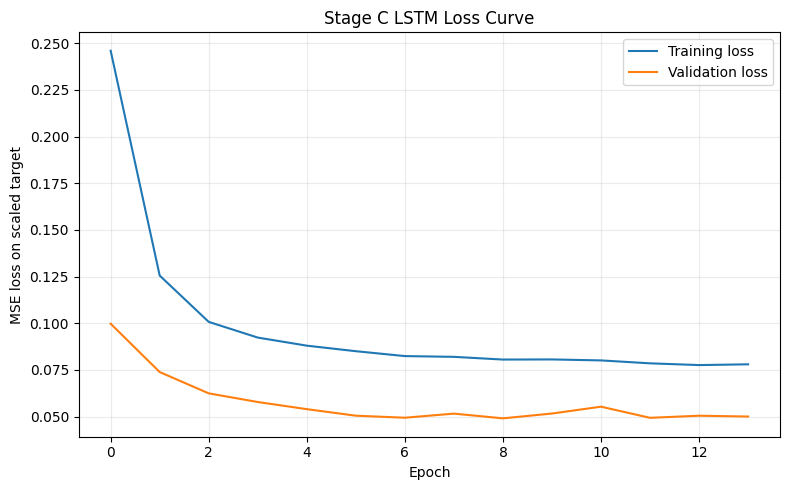

In [18]:
history_df = pd.DataFrame(history.history)
history_df.to_csv("outputs/stageC_lstm_training_history.csv", index=False)

display(history_df.tail())

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training loss")
plt.plot(history_df["val_loss"], label="Validation loss")
plt.title("Stage C LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE loss on scaled target")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("outputs/stageC_lstm_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Performance Comparison

This table compares all required model stages using the same test period. RMSE and MAE are the main metrics because the task is time-series regression and they measure the actual PM2.5 prediction error size.

In [19]:
# Re-define metrics here so the final comparison is self-contained.
def regression_metrics_dict(y_true, pred):
    y_true = np.asarray(y_true, dtype=float)
    pred = np.asarray(pred, dtype=float)
    mae = np.mean(np.abs(y_true - pred))
    rmse = np.sqrt(np.mean((y_true - pred) ** 2))
    r2 = 1 - np.sum((y_true - pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - pred[mask]) / y_true[mask])) * 100
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_percent": mape}

results_df = pd.DataFrame([
    {"Stage": "A", "Model": "NumPy Linear Regression", **regression_metrics_dict(y_test, y_pred)},
    {"Stage": "B", "Model": "Tuned Random Forest", **regression_metrics_dict(y_test, rf_pred)},
    {"Stage": "C", "Model": "LSTM sequence model", **regression_metrics_dict(y_seq_test, lstm_pred)},
])

results_df = results_df.sort_values("RMSE").reset_index(drop=True)
display(results_df)
results_df.to_csv("outputs/final_model_comparison.csv", index=False)

best_model_name = results_df.loc[0, "Model"]
print(f"Best model by RMSE: {best_model_name}")

,Stage,Model,MAE,RMSE,R2,MAPE_percent
0,B,Tuned Random Forest,11.382797,20.095033,0.951385,21.679729
1,A,NumPy Linear Regression,11.624861,20.433567,0.949733,23.023393
2,C,LSTM sequence model,11.702201,20.618588,0.948818,22.753803


Best model by RMSE: Tuned Random Forest


## Final Visualisation: Actual vs Predictions

Use this plot in the report/poster. It is more useful than numbers alone because it shows whether each model follows PM2.5 spikes and drops.

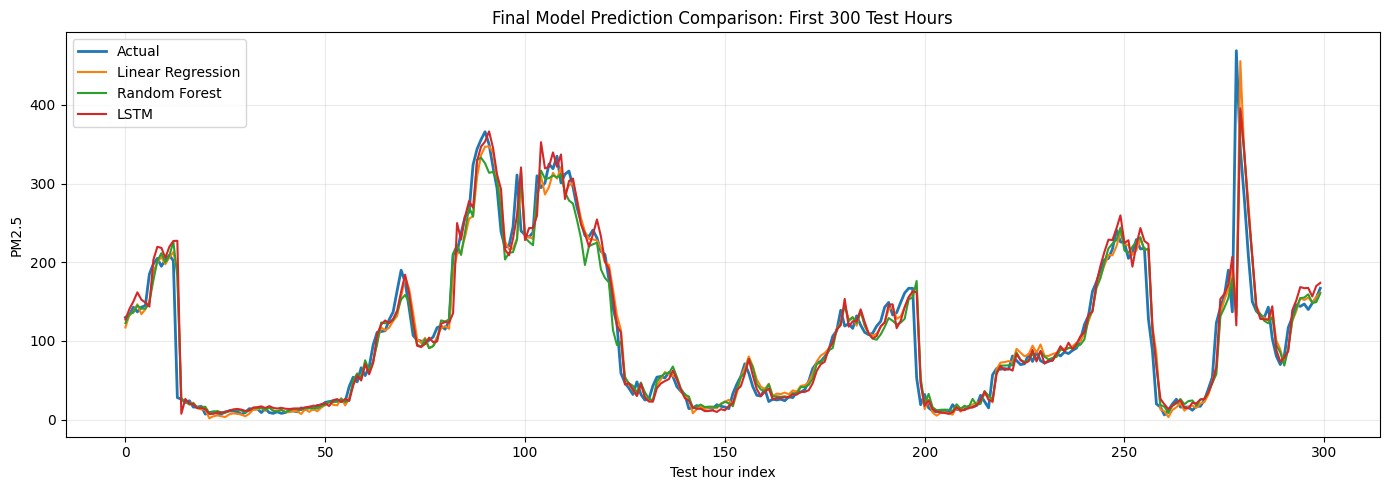

,linear_residual,rf_residual,lstm_residual
mean,0.211120,-0.589481,-1.088737
std,20.433738,20.087625,20.591076
min,-332.096842,-271.425898,-253.227753
max,500.754224,495.559278,495.043945


In [20]:
n_plot = min(300, len(y_test), len(y_seq_test))

plt.figure(figsize=(14, 5))
plt.plot(y_test[:n_plot], label="Actual", linewidth=2)
plt.plot(y_pred[:n_plot], label="Linear Regression")
plt.plot(rf_pred[:n_plot], label="Random Forest")
plt.plot(lstm_pred[:n_plot], label="LSTM")
plt.title("Final Model Prediction Comparison: First 300 Test Hours")
plt.xlabel("Test hour index")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("outputs/final_prediction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Residual summary for failure-mode analysis.
residual_df = pd.DataFrame({
    "actual": y_test[:len(lstm_pred)],
    "linear_residual": y_test[:len(lstm_pred)] - y_pred[:len(lstm_pred)],
    "rf_residual": y_test[:len(lstm_pred)] - rf_pred[:len(lstm_pred)],
    "lstm_residual": y_seq_test - lstm_pred,
})
residual_summary = residual_df[["linear_residual", "rf_residual", "lstm_residual"]].agg(["mean", "std", "min", "max"])
display(residual_summary)
residual_summary.to_csv("outputs/final_residual_summary.csv")

In [21]:
def df_to_markdown_table(df):
    rows = []
    cols = list(df.columns)
    rows.append("| " + " | ".join(cols) + " |")
    rows.append("| " + " | ".join(["---"] * len(cols)) + " |")
    for _, row in df.iterrows():
        vals = []
        for col in cols:
            val = row[col]
            if isinstance(val, (float, np.floating)):
                vals.append(f"{val:.4f}")
            else:
                vals.append(str(val))
        rows.append("| " + " | ".join(vals) + " |")
    return "\n".join(rows)

best = results_df.loc[0]
worst = results_df.loc[len(results_df) - 1]

report_text = f"""
# TTTC2453 Final Group Project Report Draft

## 1. Problem Framing and EDA

This project uses the Beijing PM2.5 hourly air quality dataset to predict PM2.5 concentration from meteorological and time-based variables. The task is framed as a time-series regression problem because the target value is continuous and the observations are ordered by hour. The cleaned dataset contains 41,757 usable rows after removing rows with missing PM2.5 target values. Only 2,067 rows were removed, which is 4.72% of the raw dataset. The removal was acceptable because the missing values were in the target column, so they could not be used for supervised model training.

Outlier analysis was performed using the IQR method. High PM2.5 values were kept because they may represent real severe pollution events, not data entry errors. Removing them would make the model weaker during high-pollution periods. The monthly PM2.5 plot confirmed that the data changes over time, so a chronological train-test split was used. The correlation heatmap showed that single weather variables only have limited linear relationship with PM2.5, so lag features and a 24-hour rolling mean were added.

Class imbalance handling is not applicable because this is not a classification task. SMOTE and class weighting are not used.

## 2. Model Principles

### Linear Regression
Linear Regression predicts PM2.5 by learning a weighted sum of the input features. It optimises the squared error between actual and predicted values. Its main assumption is that the relationship between the input variables and PM2.5 is mostly linear. This makes it easy to interpret, but it may fail when the relationship is non-linear. For this dataset, Linear Regression is useful as a baseline because the lag features, especially previous-hour PM2.5, already carry strong information.

### Random Forest
Random Forest is an ensemble model made from many decision trees. Each tree learns different decision rules from sampled data and features, then the final prediction is averaged across trees. It does not assume a straight-line relationship, so it can capture non-linear interactions between weather, wind direction, hour, month, and lagged PM2.5. Its weakness is that it is less transparent than Linear Regression and can be slower to train.

### LSTM
The LSTM model is a recurrent deep learning model designed for ordered sequence data. It uses the previous 24 hours of readings to predict the current PM2.5 value. The model learns temporal patterns through memory gates, which helps it decide what information from past hours should be kept or forgotten. This suits air pollution data because PM2.5 levels often depend on recent past conditions. However, LSTM needs more tuning and can overfit if the validation loss rises while training loss continues falling.

## 3. Model Implementation

The dataset was sorted chronologically and split into 80% training data and 20% testing data. Random shuffling was avoided to prevent look-ahead bias. The baseline model was a NumPy Linear Regression model using standardised features, lag variables, cyclic hour/month encoding, and one-hot encoded wind direction.

Stage B used a Random Forest Regressor with RandomizedSearchCV and TimeSeriesSplit. The search tested different tree counts, tree depths, split sizes, leaf sizes, and feature sampling settings. Stage C used an LSTM with a 24-hour input window, one LSTM layer, dropout, dense layers, early stopping, and a validation split taken from the training period.

## 4. Performance Analysis

The final metric table is shown below.

{df_to_markdown_table(results_df)}

The best model by RMSE is **{best['Model']}**. RMSE is used as the main metric because it penalises larger PM2.5 errors more strongly, which matters during high-pollution periods. MAE is also reported because it gives the average prediction error in the original PM2.5 unit. R² is included to show how much variation in PM2.5 is explained by the model, but it is not used alone because it does not show the real error size.

The baseline Linear Regression is useful because it is simple and interpretable. If it performs close to the more complex models, that means the lag features already explain a large part of the target. Random Forest should improve if the data contains non-linear feature interactions. The LSTM should improve when ordered 24-hour patterns are important. The prediction comparison plot should be used to check whether the models follow spikes or mostly predict smoother values.

## 5. Suitability Justification

The most suitable model for this task is **{best['Model']}** based on the current RMSE result. This choice is not based only on the lowest number. It also depends on the dataset structure. The dataset is a time-series regression dataset, so temporal order is important. A model that handles time patterns or non-linear effects is more suitable than a model that assumes a simple linear relationship. However, if the performance gap is small, the simpler model may still be preferred because it is faster and easier to explain.

## 6. Improvement Mechanisms

First, the model can be improved by adding more lag windows, such as 3-hour, 6-hour, 12-hour, and 48-hour rolling means. The current model may miss longer pollution build-up patterns, so extra rolling features would give the model stronger temporal context.

Second, the LSTM can be improved by testing different sequence lengths and hidden sizes. If the loss curve shows overfitting, dropout can be increased or the model can be made smaller. If the model underfits, the number of LSTM units or training epochs can be increased carefully.

Third, the target can be tested with log1p transformation. PM2.5 is right-skewed, so the model may struggle with extreme pollution values. A log transform may make training more stable, but predictions must be converted back to the original PM2.5 scale before evaluation.

## 7. References

- UCI Machine Learning Repository. Beijing PM2.5 Data.
- scikit-learn documentation for Linear Regression, Random Forest Regressor, RandomizedSearchCV, and TimeSeriesSplit.
- TensorFlow/Keras documentation for LSTM, EarlyStopping, and model training.
""".strip()

Path("outputs/Group8_PM25_Report_AutoDraft.md").write_text(report_text, encoding="utf-8")
print("Report draft saved to outputs/Group8_PM25_Report_AutoDraft.md")
print("Also saved: outputs/final_model_comparison.csv and required plots.")

Report draft saved to outputs/Group8_PM25_Report_AutoDraft.md
Also saved: outputs/final_model_comparison.csv and required plots.
